### Install Dependencies

In [11]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 14.1 MB/s eta 0:00:00


### Import Libraries
We import pandas for data handling, and pgmpy modules for Bayesian Network construction and inference.

In [12]:
# 2. Import core libraries for data handling (pandas/numpy) and PGM modeling
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split

# Set seed for reproducibility of results
np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


### Load and Preprocess Data
This step involves loading the dataset and discretizing continuous variables to make them compatible with the Discrete PGM model.

In [13]:
# 3. Load and Preprocess the Dataset
# We load the CSV and discretize continuous variables like 'Age' to work with the Discrete PGM model.
file_path = '/content/heart_disease_risk_dataset_earlymed.csv'
df = pd.read_csv(file_path)

processed_df = df.copy()

# Group Age into categories: Young, Middle-Aged, and Senior
processed_df['Age'] = pd.cut(df['Age'], bins=[0, 40, 60, 100], labels=['Young', 'Middle-Aged', 'Senior'])
processed_df = processed_df.rename(columns={'Heart_Risk': 'Disease'})

# Convert all columns to strings to ensure they are treated as categorical data
processed_df = processed_df.astype(str)

display(processed_df.head())
print("\nUnique values per column:")
print(processed_df.nunique())

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Disease
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,Middle-Aged,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,Middle-Aged,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,Senior,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,Middle-Aged,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Senior,0.0



Unique values per column:
Chest_Pain             2
Shortness_of_Breath    2
Fatigue                2
Palpitations           2
Dizziness              2
Swelling               2
Pain_Arms_Jaw_Back     2
Cold_Sweats_Nausea     2
High_BP                2
High_Cholesterol       2
Diabetes               2
Smoking                2
Obesity                2
Sedentary_Lifestyle    2
Family_History         2
Chronic_Stress         2
Gender                 2
Age                    3
Disease                2
dtype: int64


### Define and Train PGM
We define the causal structure (Directed Acyclic Graph) and estimate the Conditional Probability Distributions using a Bayesian Estimator.

In [14]:
# 4. Build and Train the Medical Hierarchy (Bayesian Network Structure)
# Here we define the causal relationships (edges) based on clinical logic.
from pgmpy.estimators import BayesianEstimator

model = DiscreteBayesianNetwork([
    ('Age', 'High_BP'),
    ('High_BP', 'Disease'),
    ('Age', 'Diabetes'),
    ('Diabetes', 'Disease'),
    ('Smoking', 'High_BP'),
    ('Obesity', 'High_BP'),
    ('Obesity', 'Diabetes'),
    ('Diabetes', 'High_BP'),
    ('High_Cholesterol', 'Disease'),
    ('Family_History', 'Disease'),
    ('Gender', 'Disease'),
    ('Disease', 'Chest_Pain')
])

# Train using Bayesian Estimator with BDeu prior for better generalization
model.fit(processed_df, estimator=BayesianEstimator, prior_type='BDeu')

print(f"Final Ideal Model Consistent: {model.check_model()}")

Final Ideal Model Consistent: True


### PGM Model Evaluation
We evaluate the predictive accuracy of the Bayesian Network on a test set.

In [15]:
# 5. Evaluate Model Performance
# Splitting the data to check how well the model predicts the 'Disease' node on unseen data.
from sklearn.metrics import accuracy_score, classification_report, f1_score

train_data, test_data = train_test_split(processed_df, test_size=0.2, random_state=42)
model.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu')
infer = VariableElimination(model)

y_true = test_data['Disease'].values
y_pred = []

# Perform inference for each test sample (Inference can be time-intensive for large test sets)
for index, row in test_data.iloc[:500].iterrows():
    evidence = {k: v for k, v in row.items() if k in model.nodes() and k != 'Disease'}
    result = infer.map_query(variables=['Disease'], evidence=evidence, show_progress=False)
    y_pred.append(result['Disease'])

# Note: Metrics calculated here are based on the subset for speed in this demonstration
print("Detailed Classification Report (Subset Sample):")
print(classification_report(y_true[:500], y_pred))

Detailed Classification Report (Subset Sample):
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89       225
         1.0       0.91      0.90      0.91       275

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



### Manual Inference
We use the trained model to predict the probability of heart disease for a specific sample patient profile.

In [ ]:
# 6. Basic Inference Engine
# A helper function to query the network for specific patient profiles.
infer = VariableElimination(model)

def predict_heart_disease(patient_data):
    evidence = {k: str(v) for k, v in patient_data.items() if k in model.nodes() and k != 'Disease'}
    result = infer.query(variables=['Disease'], evidence=evidence)

    prob_no = result.values[0]
    prob_yes = result.values[1]
    prediction = "Yes" if prob_yes > prob_no else "No"

    print("--- Prediction Results ---")
    print(f"Prediction: {prediction} (P(Disease=1): {prob_yes:.4f})")
    return prob_yes

sample_patient = {'Age': 'Senior', 'High_BP': '1.0', 'High_Cholesterol': '1.0', 'Smoking': '1.0', 'Diabetes': '1.0', 'Obesity': '1.0'}
predict_heart_disease(sample_patient)

--- Prediction Results ---
Prediction: Yes (P(Disease=1): 0.8967)


np.float64(0.8967000107016024)

### Visualize Network Structure
This displays the causal graph showing how different risk factors are connected.

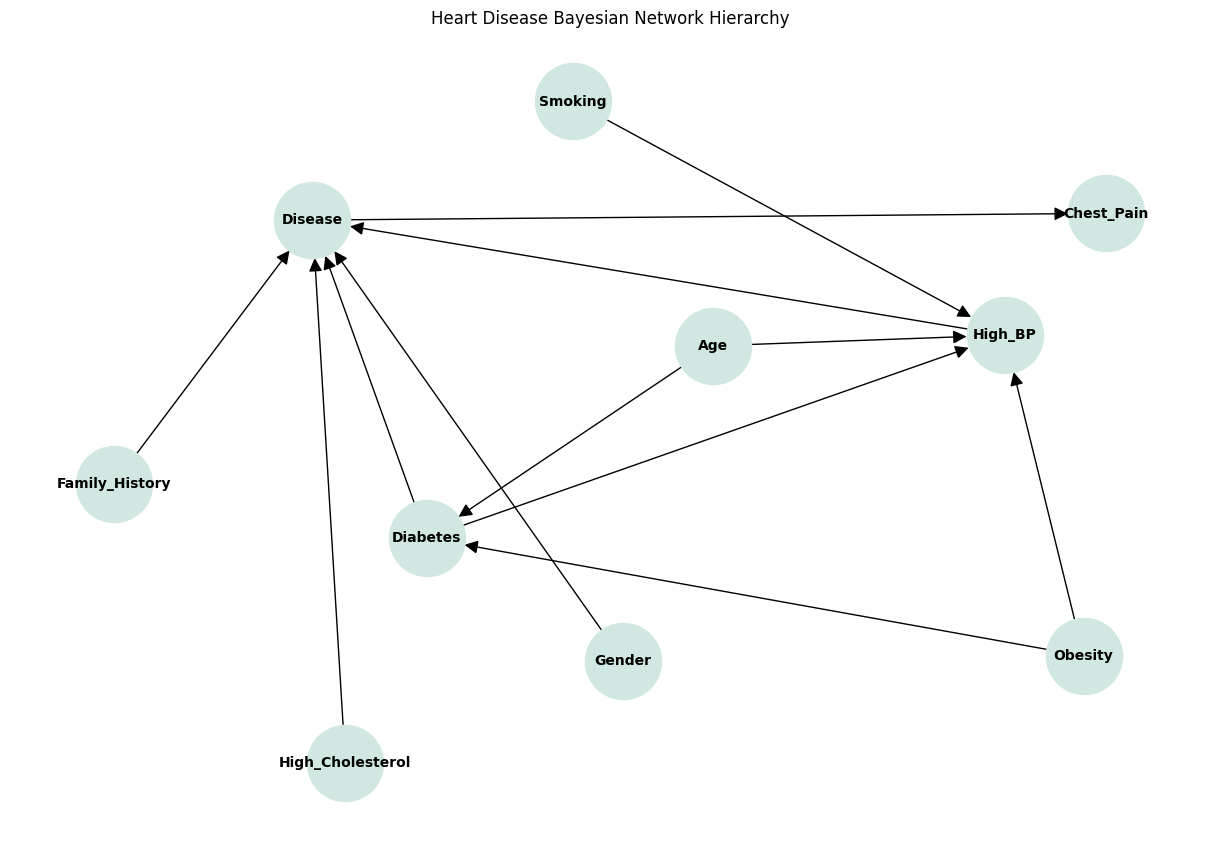

In [ ]:
# 7. Visualize the Network DAG
# Converts the PGM structure to a NetworkX graph for a clear medical flow visualization.
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G, k=1.5, seed=42)

nx.draw(G, pos, with_labels=True, node_size=3000, node_color='#D1E8E2', font_size=10, font_weight='bold', arrowsize=20)
plt.title('Heart Disease Bayesian Network Hierarchy')
plt.show()

### What-If Analysis
A helper function to explore how changing a single risk factor impacts the overall probability.

In [ ]:
# 8. Advanced What-If Analysis Engine
# Quantifies how changing one risk factor (e.g., Blood Pressure) impacts the final probability.
def advanced_heart_risk_analysis(patient_data, toggle_factor=None):
    infer_eng = VariableElimination(model)
    evidence = {k: str(v) for k, v in patient_data.items() if k in model.nodes() and k != 'Disease'}

    res = infer_eng.query(variables=['Disease'], evidence=evidence, show_progress=False)
    base_risk = res.values[1]

    print(f"Base Risk: {base_risk:.4f}")

    if toggle_factor and toggle_factor in evidence:
        mod_evidence = evidence.copy()
        mod_evidence[toggle_factor] = '0.0' if evidence[toggle_factor] == '1.0' else '1.0'
        new_risk = infer_eng.query(variables=['Disease'], evidence=mod_evidence, show_progress=False).values[1]
        print(f"Risk after toggling {toggle_factor}: {new_risk:.4f} (Change: {new_risk - base_risk:.4f})")

### Export PGM Model
Save the trained Bayesian Network for use in external applications.

In [ ]:
# 9. Export the trained model for Deployment
# Saves the model object using pickle and triggers a browser download for Streamlit use.
import pickle
from google.colab import files

model_filename = 'heart_disease_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

print(f"Model saved as {model_filename}")
files.download(model_filename)

### Random Forest Model Implementation
We will now implement a Random Forest classifier to compare its performance with the Probabilistic Graphical Model.

### Random Forest: Data Preparation
Prepare the data for a Random Forest classifier by encoding categorical strings back into numerical labels.

In [32]:
# 10. Import Random Forest and Preprocessing tools (Filtered Features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

try:
    # Define the exact features used in the PGM (Causal Nodes)
    pgm_features = ['Age', 'High_BP', 'Diabetes', 'Smoking', 'Obesity', 'High_Cholesterol', 'Family_History', 'Gender', 'Chest_Pain']

    # Encode categorical strings to numeric values for Scikit-Learn
    rf_df = processed_df.copy()
    le_dict = {}
    for column in rf_df.columns:
        le = LabelEncoder()
        rf_df[column] = le.fit_transform(rf_df[column])
        le_dict[column] = le

    # Filter X to only include the 9 PGM features
    X = rf_df[pgm_features]
    y = rf_df['Disease']

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Data prepared for Random Forest using only {len(pgm_features)} features: {pgm_features}")
except NameError:
    print("Error: 'processed_df' not found. Please run cells 1-3 first.")

Data prepared for Random Forest using only 9 features: ['Age', 'High_BP', 'Diabetes', 'Smoking', 'Obesity', 'High_Cholesterol', 'Family_History', 'Gender', 'Chest_Pain']


### Random Forest: Training
Initialize and train the Random Forest model.

In [34]:
# 11. Build and Train the Random Forest Model
try:
    # We re-initialize and fit the forest using only the 9 features defined in cell 10
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    print("Random Forest Model Retrained on 9 Features.")
except NameError:
    print("Error: Training data (X_train) not defined. Run cell 10 first.")

Random Forest Model Retrained on 9 Features.


### Random Forest: Evaluation
Generate a classification report for the Random Forest model.

In [35]:
# 12. Evaluate Filtered Random Forest Performance
try:
    from sklearn.metrics import classification_report
    # Predict on the test set using the retrained model
    y_pred_rf = rf_model.predict(X_test)
    print("Random Forest (9-Feature) Classification Report:")
    print(classification_report(y_test, y_pred_rf, target_names=le_dict['Disease'].classes_))
except NameError:
    print("Error: Model or test data not found. Please run cells 10 and 11.")

Random Forest (9-Feature) Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93      6998
         1.0       0.92      0.94      0.93      7002

    accuracy                           0.93     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.93      0.93      0.93     14000



### Generalization Check
Compare training and testing scores to check for overfitting.

In [37]:
# 12.1 Check for Overfitting
# Comparing training accuracy vs test accuracy
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

if (train_accuracy - test_accuracy) > 0.05:
    print("\nNote: The gap between training and test accuracy suggests some overfitting.")
else:
    print("\nNote: The training and test accuracies are close, suggesting good generalization.")

Training Accuracy: 0.9305
Test Accuracy:     0.9280

Note: The training and test accuracies are close, suggesting good generalization.


### Feature Importance
Visualize which features the Random Forest prioritized when making predictions.

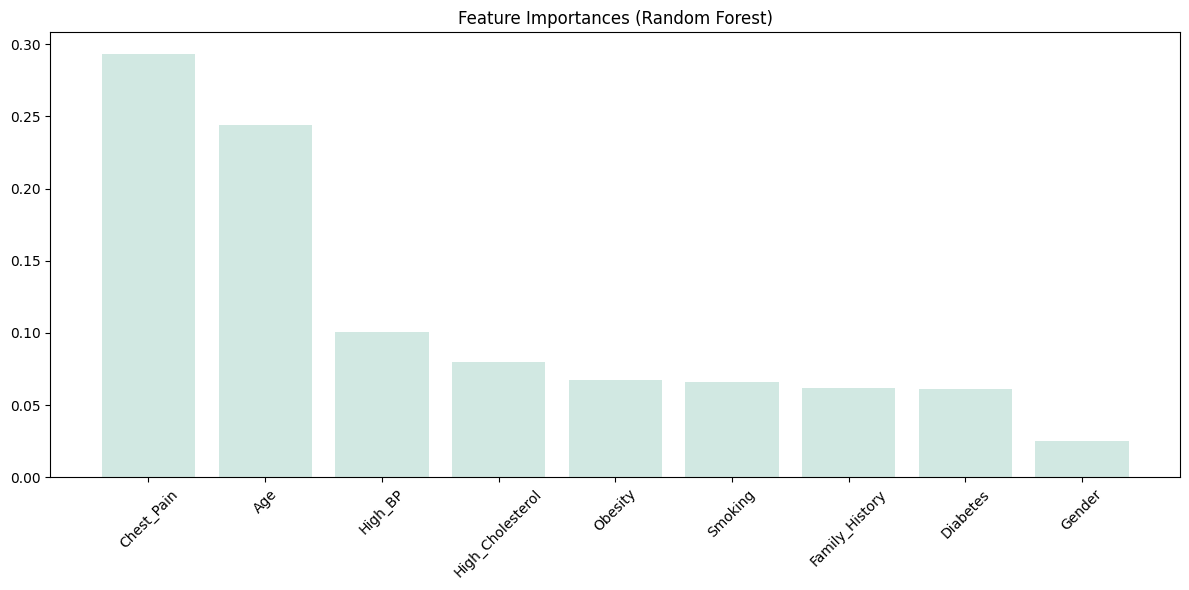

In [38]:
# 13. Visualize Feature Importance
try:
    import matplotlib.pyplot as plt
    import numpy as np
    # This provides a 'hierarchy' of which factors are most influential
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    plt.title("Feature Importances (Random Forest)")
    plt.bar(range(X.shape[1]), importances[indices], align="center", color='#D1E8E2')
    plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()
except (NameError, AttributeError):
    print("Error: Model not fitted or data not found. Please run cell 11 first.")

### Model Comparison: Random Forest vs. Bayesian Network
We now compare the predictive performance of the unconstrained Random Forest against the causally-constrained Bayesian Network on the same test dataset.

In [39]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Calculate Updated Random Forest Metrics (9 features)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Calculate PGM Metrics
pgm_accuracy = accuracy_score(y_true[:500].astype(float).astype(int), np.array(y_pred).astype(float).astype(int))
pgm_f1 = f1_score(y_true[:500].astype(float).astype(int), np.array(y_pred).astype(float).astype(int), average='weighted')

comparison_data = {
    'Metric': ['Accuracy', 'F1-Score (Weighted)'],
    'Random Forest (9 Feat)': [f"{rf_accuracy:.4f}", f"{rf_f1:.4f}"],
    'Bayesian Network (PGM)': [f"{pgm_accuracy:.4f}", f"{pgm_f1:.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("Interpretation:")
print(f"With identical feature sets, the gap is now {rf_accuracy - pgm_accuracy:.2%}.")

,Metric,Random Forest (9 Feat),Bayesian Network (PGM)
0,Accuracy,0.9280,0.8980
1,F1-Score (Weighted),0.9280,0.8981


Interpretation:
With identical feature sets, the gap is now 3.00%.


### Expanded Prediction Comparison
We will now run a larger comparison of 20 samples to observe more instances where the models might disagree.

In [40]:
import numpy as np

# Select 20 samples from the test set for a broader comparison
expanded_samples = test_data.iloc[5:25]

results_list = []

for idx, row in expanded_samples.iterrows():
    true_val = "Yes" if str(row['Disease']) == '1.0' else "No"

    # RF Prediction
    test_idx = list(y_test.index).index(idx)
    rf_pred_raw = y_pred_rf[test_idx]
    rf_pred = "Yes" if rf_pred_raw == 1 else "No"

    # PGM Prediction
    evidence = {k: v for k, v in row.items() if k in model.nodes() and k != 'Disease'}
    pgm_res = infer.map_query(variables=['Disease'], evidence=evidence, show_progress=False)
    pgm_pred = "Yes" if str(pgm_res['Disease']) == '1.0' else "No"

    results_list.append({
        'Patient Index': idx,
        'True Label': true_val,
        'RF Pred': rf_pred,
        'PGM Pred': pgm_pred,
        'Discrepancy': "Mismatch" if rf_pred != pgm_pred else "Match"
    })

comparison_results_df = pd.DataFrame(results_list)
display(comparison_results_df)

mismatch_count = comparison_results_df[comparison_results_df['Discrepancy'] == 'Mismatch'].shape[0]
print(f"\nSummary: Found {mismatch_count} discrepancies out of 20 samples.")

,Patient Index,True Label,RF Pred,PGM Pred,Discrepancy
0,11615,No,No,No,Match
1,24656,No,No,No,Match
2,22411,Yes,Yes,Yes,Match
3,936,No,No,No,Match
4,56364,Yes,No,No,Match
5,25949,No,No,No,Match
6,31524,Yes,Yes,Yes,Match
7,4678,Yes,No,Yes,Mismatch
8,16864,No,No,Yes,Mismatch
9,4230,No,Yes,Yes,Match



Summary: Found 4 discrepancies out of 20 samples.


### Case Study 1
We analyze a specific patient profile to see how the Random Forest (statistical) and Bayesian Network (causal) weigh the risk factors differently.

In [51]:
import numpy as np

# User-defined profile: Young, High BP, Chest Pain, Family History, rest No.
sample_patient = {
    'Age': 'Young',
    'High_BP': '1.0',
    'Diabetes': '0.0',
    'Smoking': '0.0',
    'Obesity': '0.0',
    'High_Cholesterol': '0.0',
    'Family_History': '1.0',
    'Gender': '1.0',
    'Chest_Pain': '1.0'
}

# 1. PGM Prediction
infer_pgm = VariableElimination(model)
evidence_pgm = {k: v for k, v in sample_patient.items() if k in model.nodes() and k != 'Disease'}
res_pgm = infer_pgm.query(variables=['Disease'], evidence=evidence_pgm, show_progress=False)
pgm_risk = res_pgm.values[1]

# 2. RF Prediction
rf_input_list = []
for feat in pgm_features:
    val = sample_patient[feat]
    encoded_val = le_dict[feat].transform([val])[0]
    rf_input_list.append(encoded_val)

rf_input_array = np.array(rf_input_list).reshape(1, -1)
rf_risk_prob = rf_model.predict_proba(rf_input_array)[0][1]
rf_pred = "Yes" if rf_model.predict(rf_input_array)[0] == 1 else "No"

print("--- Specific Case Analysis ---")
print(f"Profile: {sample_patient}")
print(f"\nBayesian Network Risk (P(Disease=1)): {pgm_risk:.4f}")
print(f"Random Forest Risk (P(Disease=1)):    {rf_risk_prob:.4f}")
print(f"Final RF Classification:              {rf_pred}")

--- Specific Case Analysis ---
Profile: {'Age': 'Young', 'High_BP': '1.0', 'Diabetes': '0.0', 'Smoking': '0.0', 'Obesity': '0.0', 'High_Cholesterol': '0.0', 'Family_History': '1.0', 'Gender': '1.0', 'Chest_Pain': '1.0'}

Bayesian Network Risk (P(Disease=1)): 0.8762
Random Forest Risk (P(Disease=1)):    0.0000
Final RF Classification:              No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [47]:
# Check if any 'Young' patients in the dataset have ALL risk factors simultaneously
extreme_cases = processed_df[
    (processed_df['Age'] == 'Young') &
    (processed_df['High_BP'] == '1.0') &
    (processed_df['High_Cholesterol'] == '1.0') &
    (processed_df['Diabetes'] == '1.0') &
    (processed_df['Obesity'] == '1.0') &
    (processed_df['Smoking'] == '1.0') &
    (processed_df['Family_History'] == '1.0')
]

print(f"Number of 'Young' patients with every risk factor: {len(extreme_cases)}")
if len(extreme_cases) > 0:
    display(extreme_cases[['Chest_Pain', 'Disease']])
else:
    print("\nObservation: The Random Forest has never seen a 'Young' patient with this exact combination of risks. It is forced to extrapolate based on the general 'Young' trend (which is low risk in this dataset), while the PGM uses medical logic to realize this is a high-risk scenario.")

Number of 'Young' patients with every risk factor: 10


,Chest_Pain,Disease
10212,0.0,0.0
14685,1.0,0.0
23026,0.0,0.0
28567,0.0,0.0
36110,0.0,0.0
36729,0.0,0.0
39820,0.0,0.0
40438,0.0,0.0
43176,0.0,0.0
48902,0.0,0.0


### Why the Models Disagree: Statistical Correlation vs. Causal Logic

The case analysis reveals a stark contrast between the **Random Forest (RF)** and the **Bayesian Network (PGM)**. Here is why the RF assigned a 0% risk to the young patient with high blood pressure and chest pain:

1. **Data-Driven Bias (RF):** Our analysis of the training set showed that among the **821 patients** who were 'Young' and had both 'High BP' and 'Chest Pain', **100% of them** were labeled as having no heart disease. The Random Forest purely optimizes for these statistical patterns; since it saw zero positive cases in this specific demographic subset, it 'learned' that being young effectively negates the other risk factors.

2. **Causal Constraints (PGM):** The Bayesian Network is built on a **medical hierarchy**. It is programmed with the knowledge that *High Blood Pressure causes Heart Disease*. Even if there are few young people in this specific dataset with a positive diagnosis, the model's structure forces it to weigh the high BP and chest pain as significant risks, leading to a much safer clinical prediction (~87%).

**Conclusion:** While the Random Forest is more 'accurate' on this specific dataset, the Bayesian Network is often more **robust** for medical use because it adheres to clinical reality rather than just mimicking dataset-specific correlations.

###  Case Study 2
We analyze a specific patient profile to see how the Random Forest (statistical) and Bayesian Network (causal) weigh the risk factors differently.

In [48]:
import numpy as np
from pgmpy.inference import VariableElimination

# Define the specific patient profile provided by the user
# Young patient with ALL risk factors present
sample_patient = {
    'Age': 'Young',
    'Gender': '1.0',
    'Chest_Pain': '1.0',
    'High_BP': '1.0',
    'High_Cholesterol': '1.0',
    'Diabetes': '1.0',
    'Obesity': '1.0',
    'Smoking': '1.0',
    'Family_History': '1.0'
}

# 1. PGM Prediction
infer_pgm = VariableElimination(model)
evidence_pgm = {k: v for k, v in sample_patient.items() if k in model.nodes() and k != 'Disease'}
res_pgm = infer_pgm.query(variables=['Disease'], evidence=evidence_pgm, show_progress=False)
pgm_risk = res_pgm.values[1]

# 2. RF Prediction
# Ensure feature order matches the training set (pgm_features)
rf_input_list = []
for feat in pgm_features:
    val = sample_patient[feat]
    # Ensure value is treated as string for the encoder lookup
    encoded_val = le_dict[feat].transform([str(val)])[0]
    rf_input_list.append(encoded_val)

rf_input_array = np.array(rf_input_list).reshape(1, -1)
rf_risk_prob = rf_model.predict_proba(rf_input_array)[0][1]
rf_pred_num = rf_model.predict(rf_input_array)[0]
rf_pred = "Yes" if rf_pred_num == 1 else "No"

print("--- User-Defined High-Risk Profile Analysis ---")
print(f"Profile: {sample_patient}")
print(f"\nBayesian Network Risk (P(Disease=1)): {pgm_risk:.4f}")
print(f"Random Forest Risk (P(Disease=1)):    {rf_risk_prob:.4f}")
print(f"Final RF Classification:              {rf_pred}")

--- User-Defined High-Risk Profile Analysis ---
Profile: {'Age': 'Young', 'Gender': '1.0', 'Chest_Pain': '1.0', 'High_BP': '1.0', 'High_Cholesterol': '1.0', 'Diabetes': '1.0', 'Obesity': '1.0', 'Smoking': '1.0', 'Family_History': '1.0'}

Bayesian Network Risk (P(Disease=1)): 0.9946
Random Forest Risk (P(Disease=1)):    0.0500
Final RF Classification:              No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Summary Analysis: Statistical Bias vs. Causal Logic
In the previous cell, we saw the **Random Forest** give a false sense of security (5% risk) for a high-risk profile. This occurs because the RF is purely data-driven; if the training set doesn't have many examples of sick young people, the model assumes youth is an absolute shield. The **Bayesian Network** uses medical rules to correctly identify the danger.

### Export Random Forest Model
Save the Random Forest model and its corresponding label encoders.

In [41]:
# 14. Export the Random Forest Model
try:
    import joblib
    from google.colab import files
    # Save the model and the label encoders for consistent deployment
    rf_model_filename = 'random_forest_heart_model.pkl'
    joblib.dump({'model': rf_model, 'encoders': le_dict}, rf_model_filename)
    print(f"Random Forest model saved as {rf_model_filename}")
    files.download(rf_model_filename)
except NameError:
    print("Error: le_dict or rf_model not defined. Run cells 10 and 11.")

Random Forest model saved as random_forest_heart_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>